In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, Imputer
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix

In [0]:
df = spark.read.csv("/Volumes/workspace/default/datasetfile/train.csv",header=True,inferSchema=True)
display(df)

Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
LP001002,Male,No,0,Graduate,No,5849,0.0,null,360,1,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128,360,1,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66,360,1,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360,1,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141,360,1,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267,360,1,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95,360,1,Urban,Y
LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158,360,0,Semiurban,N
LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168,360,1,Urban,Y
LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349,360,1,Semiurban,N


In [0]:
df.printSchema()
print("Total rows:", df.count())

root
 |-- Loan_ID: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Married: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- Education: string (nullable = true)
 |-- Self_Employed: string (nullable = true)
 |-- ApplicantIncome: integer (nullable = true)
 |-- CoapplicantIncome: double (nullable = true)
 |-- LoanAmount: integer (nullable = true)
 |-- Loan_Amount_Term: integer (nullable = true)
 |-- Credit_History: integer (nullable = true)
 |-- Property_Area: string (nullable = true)
 |-- Loan_Status: string (nullable = true)

Total rows: 614


In [0]:
df = df.drop("Loan_ID")
df = df.fillna({"Gender": "Unknown","Married": "Unknown","Dependents": "0","Self_Employed": "No"})

In [0]:
categorical_cols = ["Gender","Married","Dependents","Education","Self_Employed","Property_Area"]
numerical_cols = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]
label_col = "Loan_Status"

In [0]:
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

In [0]:
indexers = [
StringIndexer(inputCol=col, outputCol=col+"_Index", handleInvalid="keep")
for col in categorical_cols
]

label_indexer = StringIndexer(
inputCol=label_col,
outputCol="label"
)

In [0]:
imputer = Imputer(
inputCols=numerical_cols,
outputCols=[col+"_Imputed" for col in numerical_cols],
strategy="median"
)

In [0]:
feature_cols = [col+"_Index" for col in categorical_cols] + \
               [col+"_Imputed" for col in numerical_cols]

assembler = VectorAssembler(
inputCols=feature_cols,
outputCol="features"
)

In [0]:
dt = DecisionTreeClassifier(
featuresCol="features",
labelCol="label",
maxDepth=5
)

In [0]:
pipeline = Pipeline(
stages=indexers + [label_indexer, imputer, assembler, dt]
)

model = pipeline.fit(train_data)

In [0]:
predictions = model.transform(test_data)

display(predictions.select("prediction","label"))

prediction,label
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
1.0,1.0
0.0,0.0
0.0,0.0
0.0,0.0
0.0,0.0
1.0,1.0


In [0]:
evaluator_acc = MulticlassClassificationEvaluator(
labelCol="label",
predictionCol="prediction",
metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
labelCol="label",
predictionCol="prediction",
metricName="f1"
)

accuracy = evaluator_acc.evaluate(predictions)
f1_score = evaluator_f1.evaluate(predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1_score)

Accuracy: 0.782608695652174
F1 Score: 0.7541501976284585


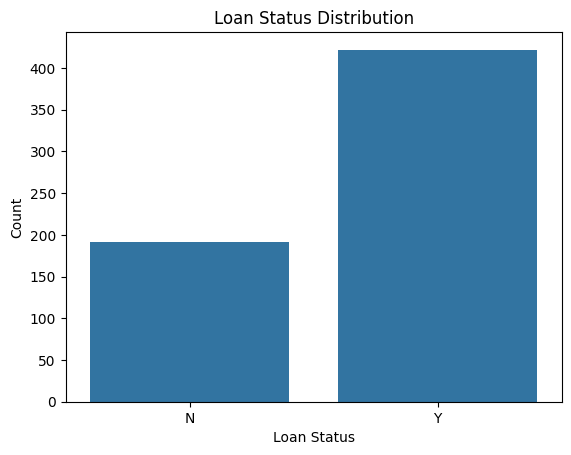

In [0]:
loan_status_pd = df.groupBy("Loan_Status").count().toPandas()

sns.barplot(x="Loan_Status", y="count", data=loan_status_pd)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

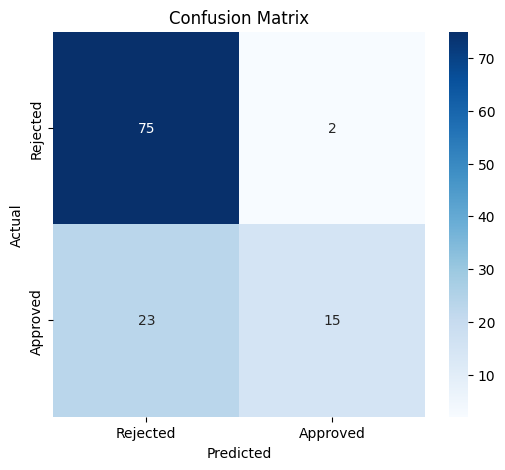

In [0]:
preds_and_labels = predictions.select("prediction","label").toPandas()

cm = confusion_matrix(
preds_and_labels["label"],
preds_and_labels["prediction"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
cm,
annot=True,
fmt="d",
cmap="Blues",
xticklabels=["Rejected","Approved"],
yticklabels=["Rejected","Approved"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

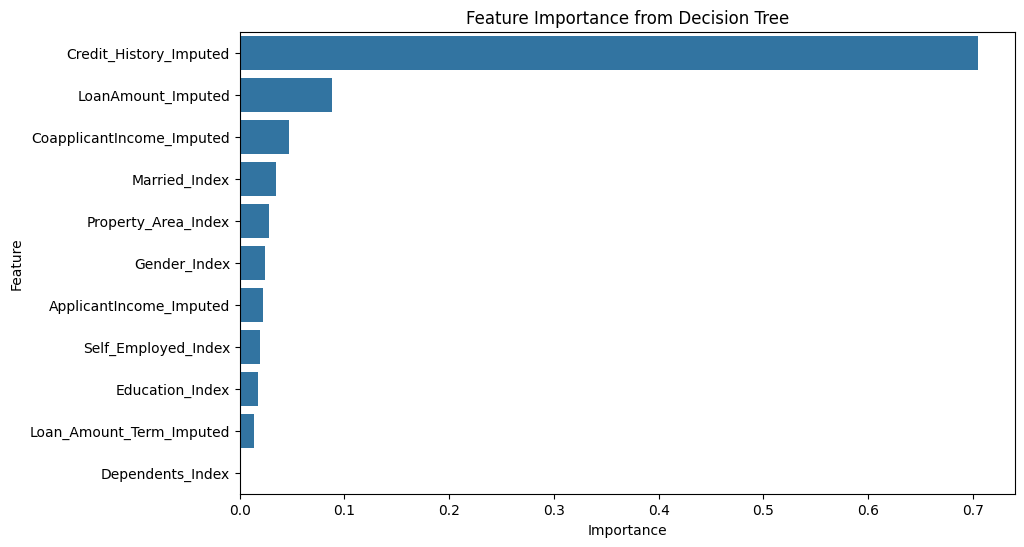

In [0]:
tree_model = model.stages[-1]

importances = tree_model.featureImportances.toArray()

importance_df = pd.DataFrame({
"Feature": feature_cols,
"Importance": importances
})

importance_df = importance_df.sort_values(
by="Importance",
ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
x="Importance",
y="Feature",
data=importance_df
)

plt.title("Feature Importance from Decision Tree")
plt.show()

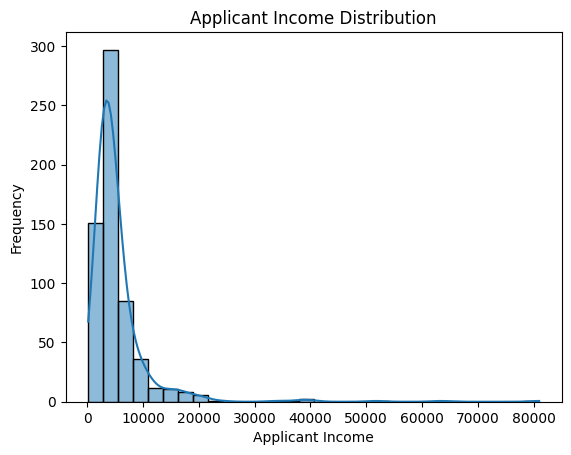

In [0]:
income_df = df.select("ApplicantIncome").toPandas()

sns.histplot(income_df["ApplicantIncome"], bins=30, kde=True)

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()